In [15]:
78 * 1.3

101.4

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
active_cells1_file_Name  = 'C:/Users/fn101139/Documents/SamsungSwap/11-14-2022/nationwide_cells_SS_Cband_cmw.xlsx'

active_cells2_file_Name  = 'C:/Users/fn101139/Documents/SamsungSwap/12-12-2022/nationwide_cells_SS_cBand_cmW.xlsx'


In [17]:
active_cells1_file_Name  = 'C:/Users/fn101139/Documents/SamsungSwap/05-16-2022/nationwide_cells_SS_Cband_cmw.xlsx'

active_cells2_file_Name  = 'C:/Users/fn101139/Documents/SamsungSwap/05-23-2022/nationwide_cells_SS_cBand_cmW.xlsx'


In [3]:
calculate_delta = True

nokia_colors = [(18/255, 65/255, 145/255), 
                # (0/255, 17/255, 53/255), (237/255, 242/255, 245/255),
                (190/255, 200/255, 210/255),(152/255, 162/255, 174/255), (77/255, 87/255, 102/255),
                (39/255, 49/255, 66/255), (0/255, 201/255, 255/255), (75/255, 221/255, 51/255)] 

markets_regions = 'C:/Users/fn101139/Documents/SamsungSwap/06-13-2022/sectorResult_permarket.xlsx'


In [19]:
market_result = pd.read_excel(markets_regions,   sheet_name = 'Sheet1')


In [4]:
if calculate_delta : 
  active_cells1 = pd.read_excel (active_cells1_file_Name, sheet_name = 'Sheet1')
  print ('read 1 finish')

read 1 finish


In [5]:
active_cells_05_16 = pd.read_excel ('C:/Users/fn101139/Documents/SamsungSwap/05-16-2022/nationwide_cells_SS_cBand_cmW.xlsx', sheet_name = 'Sheet1')


In [23]:
active_cells_05_31 = pd.read_excel ('C:/Users/fn101139/Documents/SamsungSwap/05-31-2022/nationwide_cells_SS_cBand_cmW.xlsx', sheet_name = 'Sheet1')


In [18]:
active_cells_june_16_cm_SS = set (active_cells_05_16.nrCellId)

In [24]:
active_cells_june_31_cm_SS = set (active_cells_05_31.nrCellId)

In [22]:
delta1 = (active_cells_june_16_cm_SS - active_cells_june_23_cm_SS)

In [26]:
delta2 = (active_cells_june_23_cm_SS - active_cells_june_31_cm_SS)

In [16]:
active_cells_june_23_cm_SS = set (active_cells_June_23['nrCellId'])

In [10]:
active_cells_june_15_cm_SS = set (active_cells_June_15.loc [ (active_cells_June_15.freqType == 'cmW') &
                                                       (~ active_cells_June_15.Nokia), 'nrCellId'])

In [22]:
def delta_cells_in_df  (active_cactive_cells_June_15ells1, active_cells2):

    active_cell_set2 = set (active_cells2 ['nrCellId'])
    active_cell_set1 = set (active_cells1 ['nrCellId'])
    
    delta_cells_set = active_cell_set2 - active_cell_set1
    delta_cells_df = pd.DataFrame (delta_cells_set)
    delta_cells_df.columns  = ["cells"]
    active_cells1.convert_dtypes(convert_integer = True)

    return delta_cells_df.merge (active_cells2, how = 'left', left_on = 'cells', right_on = 'nrCellId')


In [24]:
print ('dataframe shape active cells', active_cells.shape[0], active_cells.shape[1], active_cells.columns)

print ('cband added : ', sum ((active_cells ['freqType'] == 'cBand')))
print ('cmW (SS) added : ', sum ((active_cells ['freqType'] == 'cmW') & (~active_cells.Nokia)))
print ('cmW (Nokia) added : ', sum ((active_cells ['freqType'] == 'cmW') & (active_cells.Nokia)))
print ('mmW (SS) added : ', sum ((active_cells ['freqType'] == 'mmW') & (~active_cells.Nokia)))
print ('mmW (Nokia) added : ', sum ((active_cells ['freqType'] == 'mmW') & (active_cells.Nokia)))


dataframe shape active cells 157 18 Index(['cells', 'Unnamed: 0.1', 'Unnamed: 0', 'Global eNodeB ID',
       'Full Object Path', 'nrCellId', 'lncel', 'lnRelGnbCell', 'nbrGnbId',
       'nbrCellId', 'marketId', 'freqType', 'uniqueSector', 'inMarket',
       'Nokia', 'cBandNokia', '#gNB cBand Sectors', '#gNB cm Sectors'],
      dtype='object')
cband added :  9
cmW (SS) added :  148
cmW (Nokia) added :  0
mmW (SS) added :  0
mmW (Nokia) added :  0


In [25]:
VzMarketIdList = market_result['Market'].tolist()

regions =  market_result [ ['Market', 'Region']]

regions.set_index('Market')

#the following adds region to the frame based on the market ID
active_cells = active_cells.join(regions.set_index('Market'), on= 'marketId', how = 'left') 

active_cells.fillna( {'#gNB cBand Sectors' : 0, '#gNB cm Sectors' : 0 }, inplace = True )
active_cells ['total gNB size'] = active_cells ['#gNB cBand Sectors' ] + active_cells ['#gNB cm Sectors' ]

active_cells ['isCloud']  = active_cells ['total gNB size'] > 10
active_cells ['isBM']  = active_cells ['total gNB size'] < 5



In [26]:

region_result = active_cells.groupby (['Region', 'freqType', 'Nokia', 'isBM']) ['nrCellId'].count()
region_df = region_result.to_frame().reset_index()
print ('results per region :')
print (region_df)


results per region :
                    Region freqType  Nokia   isBM  nrCellId
0            Central Texas      cmW  False   True         3
1       Houston/Gulf Coast      cmW  False   True         3
2           New York Metro      cmW  False  False         6
3           New York Metro      cmW  False   True        15
4                     Ohio    cBand  False  False         7
5                     Ohio    cBand  False   True         1
6                     Ohio      cmW  False  False         6
7                     Ohio      cmW  False   True         3
8   Philadelphia Tri-State      cmW  False   True         2
9            South Central    cBand  False  False         1
10           South Central      cmW  False  False         2
11       Southern Virginia      cmW  False   True       108


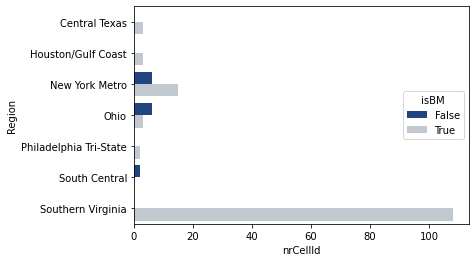

In [27]:
plot_me = region_df [region_df ['freqType'] == 'cmW']
ax = sns.barplot(y="Region", x="nrCellId", hue="isBM", data=plot_me, palette=nokia_colors)



In [14]:

region_df.to_excel ('region_result.xlsx')



new_cell_cBand_cloud = sum ((active_cells ['freqType'] == 'cBand') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] > 10))

new_cell_cBand_bm  = sum ((active_cells ['freqType'] == 'cBand') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] < 5)) 

new_cell_cBand_unknown  = sum ((active_cells ['freqType'] == 'cBand') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] > 4) & 
                                    (active_cells [ 'total gNB size'] < 11) ) 



new_cell_cmW_cloud  = sum ((active_cells ['freqType'] == 'cmW') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] > 10 ))
new_cell_cmW_bm  = sum ((active_cells ['freqType'] == 'cmW') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] < 5 ))

new_cell_cmW_unknown  = sum ((active_cells ['freqType'] == 'cmW') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] > 4 )& 
                                    (active_cells [ 'total gNB size'] < 11 ))



print (" cBand cloud: ", new_cell_cBand_cloud)
print (" cBand BM: ", new_cell_cBand_bm)
print (" cBand unknown: ", new_cell_cBand_unknown)

print (" cmW cloud: ",  new_cell_cmW_cloud)
print (" cmW BM: ", new_cell_cmW_bm)
print (" cmW unknown: ", new_cell_cmW_unknown)

  
new_gNB_cmW_bm = active_cells.loc [(active_cells ['freqType'] == 'cmW') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] < 5), 'nbrGnbId'].unique ()

new_gNB_cmW_cloud = active_cells.loc [(active_cells ['freqType'] == 'cmW') & 
                                    (~ active_cells.Nokia) & 
                                    (active_cells [ 'total gNB size'] > 10), 'nbrGnbId'].unique ()



print ("new gNB:", new_gNB_cmW_bm, new_gNB_cmW_cloud)

 cBand cloud:  316
 cBand BM:  5
 cBand unknown:  20
 cmW cloud:  142
 cmW BM:  76
 cmW unknown:  13
new gNB: [1269747 1209634 1219156 1209622 1369143 2509677 1079143 1009170 1139381
 2419740  979745 1009411 2509831 1219328 1219238 1209336 1209669 1009049
 2439517 1269614 1009970 1009082 1139386 1219067  989087] [ 899350 1369351  809210 1139450 1139451  829310 2519580 1209003 1849201
  859450  889100 2439200 1009701  829300 1029751 1379403 1329150 1209001
 1219101 1219103  819262  979452 1119350 2469401  979453 1329152 1369352
 1269601 1269602  799150  869251 2539101 2429250  919200 2439203 1849200
  819252 1229201 1369354 1029750 1339201  849410  989500 2439202  809200
  889101  999650 2429252 1829153 2539100  999651]


In [32]:
active_cells2

,Unnamed: 0.1,Unnamed: 0,Global eNodeB ID,Full Object Path,nrCellId,lncel,lnRelGnbCell,nbrGnbId,nbrCellId,marketId,freqType,uniqueSector,inMarket,Nokia,cBandNokia,#gNB cBand Sectors,#gNB cm Sectors
0,9,9,78802,MRBTS-78802/LNBTS-78802/LNCEL-1/LNRELGNBCELL-0,12928617290,1,0,789100,2890,78,cBand,7880200,True,False,True,60.0,NaN
1,10,10,78802,MRBTS-78802/LNBTS-78802/LNCEL-1/LNRELGNBCELL-1,12928617306,1,1,789100,2906,78,cBand,7880200,True,False,True,60.0,NaN
2,11,11,78802,MRBTS-78802/LNBTS-78802/LNCEL-1/LNRELGNBCELL-2,12928617322,1,2,789100,2922,78,cBand,7880200,True,False,True,60.0,NaN
3,12,12,78802,MRBTS-78802/LNBTS-78802/LNCEL-1/LNRELGNBCELL-3,12928617994,1,3,789100,3594,78,cBand,7880200,True,False,True,60.0,NaN
4,13,13,78802,MRBTS-78802/LNBTS-78802/LNCEL-1/LNRELGNBCELL-4,12928618010,1,4,789100,3610,78,cBand,7880200,True,False,True,60.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12400,64554,1865,253457,MRBTS-253457/LNBTS-253457/LNCEL-3/LNRELGNBCELL-0,41600615818,3,0,2539100,1418,253,cBand,25345700,True,False,False,188.0,58.0
12401,64555,1866,253474,MRBTS-253474/LNBTS-253474/LNCEL-1/LNRELGNBCELL-1,41600619594,1,1,2539100,5194,253,cBand,25347400,True,False,False,188.0,58.0
12402,64559,1870,253486,MRBTS-253486/LNBTS-253486/LNCEL-1/LNRELGNBCELL-1,41600615354,1,1,2539100,954,253,cBand,25348600,True,False,False,188.0,58.0
12403,64560,1871,253486,MRBTS-253486/LNBTS-253486/LNCEL-1/LNRELGNBCELL-2,41600615370,1,2,2539100,970,253,cBand,25348600,True,False,False,188.0,58.0
